# Ejemplo de taller de redes neuronales con datos de SP500


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf


warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
start_date = '1945-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']

precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']

precios_close.dropna(axis=1, inplace=True)

[*********************100%***********************]  23 of 23 completed


In [3]:
precios_close.dropna(axis=1, inplace=True)

In [4]:
returns = np.log(precios_close).diff().dropna()
returns.shape

(16184, 23)

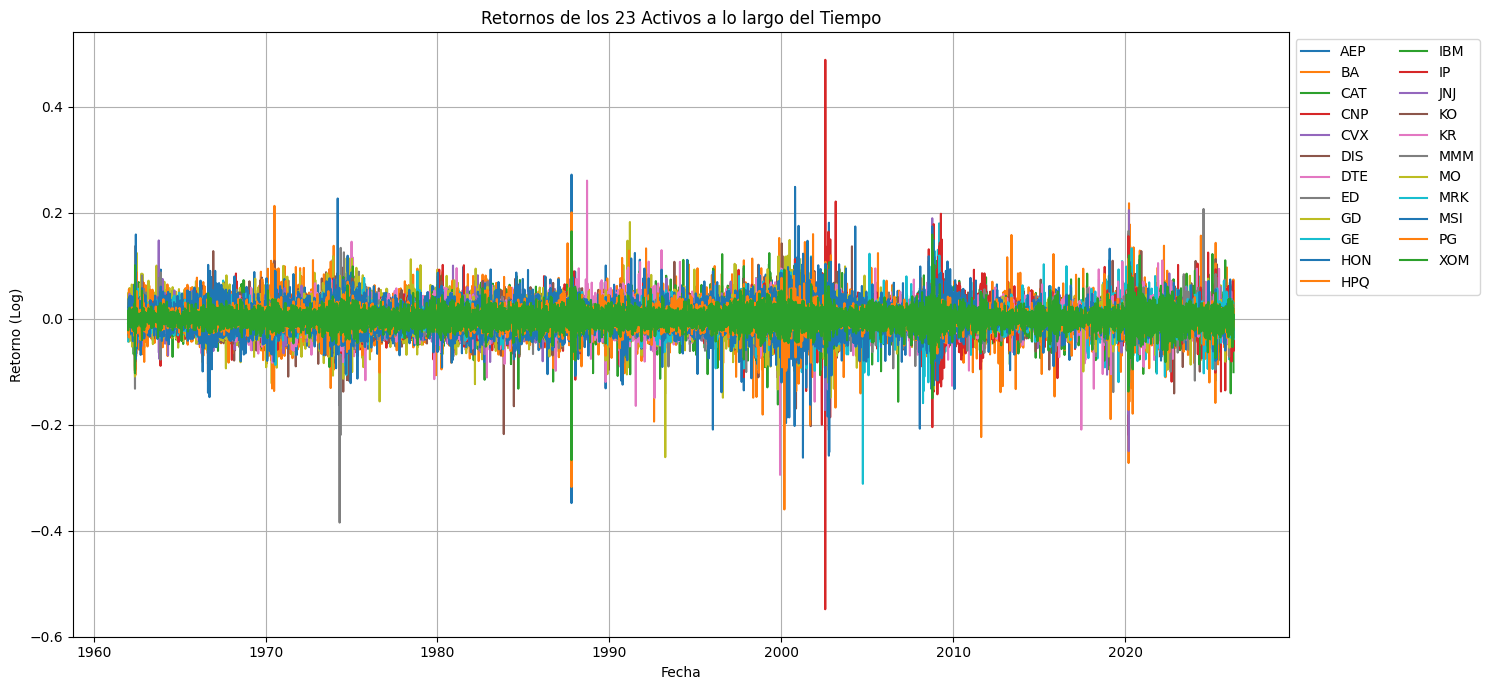

In [5]:
plt.figure(figsize=(15, 7))
plt.plot(returns)
plt.title('Retornos de los 23 Activos a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Retorno (Log)')
plt.legend(returns.columns, loc='upper left', bbox_to_anchor=(1, 1), ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# Partir los datos en ventanas

In [ ]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

In [ ]:
# Definir los tamaños de ventana
input_window_size = 10  # Por ejemplo, 10 días de retornos como entrada
output_window_size = 5 # Por ejemplo, el promedio del siguiente día como salida

# Generar series temporales para el conjunto de entrenamiento
X, y = create_time_series_data(returns, input_window_size, output_window_size)


In [ ]:
print(X.shape)
print(y.shape)

(16167, 10, 23)
(16167, 23)


In [ ]:
from sklearn.model_selection import train_test_split

# Set a random seed for reproducibility
RANDOM_SEED = 42

# Split the time series sequences X and y into training and testing sets (90% train, 10% test)
# shuffle=False is crucial for time series data to maintain chronological order
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X, y, test_size=0.1, shuffle=False, random_state=RANDOM_SEED
)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (14550, 10, 23)
Shape of y_train_seq: (14550, 23)
Shape of X_test_seq: (1617, 10, 23)
Shape of y_test_seq: (1617, 23)
